# Demo DocNLC trên CPU

Notebook này dùng để demo inference cho project **DocNLC: A Document Image Enhancement Framework with Normalized and Latent Contrastive Representation for Multiple Degradations**.

Ý nghĩa ngắn gọn của dự án: DocNLC khôi phục ảnh tài liệu bị suy giảm bởi nhiều loại nhiễu như blur, noise, shadow, watermark hoặc nền phức tạp. Model dùng kiến trúc kiểu U-Net (`SeeInDark`) kết hợp khối chuẩn hóa/contrast trong tầng đầu (`AttING`) để tăng cường ảnh tài liệu. Notebook này load checkpoint có sẵn, chạy inference hoàn toàn bằng CPU, rồi lưu và hiển thị kết quả.

In [3]:
# Bỏ comment và chạy cell này nếu kernel chưa có PyTorch bản CPU.
# %pip install torch torchvision --index-url https://download.pytorch.org/whl/cpu

## 1. Setup môi trường

Chạy cell này trước. Notebook khóa thiết bị về CPU nên không yêu cầu CUDA hoặc GPU. Nếu kernel chưa có PyTorch, cài wheel CPU theo lệnh được in ra.

In [4]:
import importlib.util
import subprocess
import sys

INSTALL_BASIC_DEPS = True

def has_module(name: str) -> bool:
    return importlib.util.find_spec(name) is not None

def pip_install(*packages: str):
    cmd = [sys.executable, "-m", "pip", "install", "-q", *packages]
    print("Running:", " ".join(cmd))
    subprocess.check_call(cmd)

if INSTALL_BASIC_DEPS:
    required = {
        "numpy": "numpy",
        "cv2": "opencv-python",
        "PIL": "pillow",
        "matplotlib": "matplotlib",
        "yaml": "pyyaml",
        "tqdm": "tqdm",
    }
    missing = [pkg for module, pkg in required.items() if not has_module(module)]
    if missing:
        pip_install(*missing)

if not has_module("torch"):
    print("PyTorch chưa được cài trong kernel này.")
    print("Cài PyTorch CPU bằng lệnh:")
    print(f"{sys.executable} -m pip install torch torchvision --index-url https://download.pytorch.org/whl/cpu")
    raise RuntimeError("Hãy cài PyTorch CPU rồi chạy lại notebook.")

print("Setup cơ bản đã sẵn sàng.")

Setup cơ bản đã sẵn sàng.


## 2. Import thư viện và thiết lập CPU

In [5]:
from pathlib import Path
import os
import sys
import time

import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from tqdm.auto import tqdm

import torch

print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)

# Luôn chạy CPU, kể cả khi kernel nhìn thấy GPU.
device = torch.device("cpu")
CPU_THREADS = max(1, min(8, os.cpu_count() or 1))  # Có thể giảm nếu cần dành CPU cho ứng dụng khác.
torch.set_num_threads(CPU_THREADS)
print("Device:", device)
print("CPU threads:", torch.get_num_threads())
device

Python: 3.12.5
PyTorch: 2.12.0
Device: cpu
CPU threads: 8


device(type='cpu')

## 3. Khai báo đường dẫn project, checkpoint và ảnh demo

Notebook này nên được đặt trong root project `DocNLC`. Nếu bạn chạy ở thư mục khác, chỉnh `PROJECT_ROOT` cho đúng.

In [6]:
PROJECT_ROOT = Path.cwd()

# Nếu notebook không được mở từ root repo, tự tìm lên các thư mục cha.
if not (PROJECT_ROOT / "models" / "archs" / "EnhanceN_arch.py").exists():
    for parent in PROJECT_ROOT.parents:
        if (parent / "models" / "archs" / "EnhanceN_arch.py").exists():
            PROJECT_ROOT = parent
            break

assert (PROJECT_ROOT / "models" / "archs" / "EnhanceN_arch.py").exists(), "Không tìm thấy root project DocNLC. Hãy chỉnh PROJECT_ROOT."

# Dat path den checkpoint best ban muon kiem tra.
# CKPT_PATH = PROJECT_ROOT / "ckpts" / "26_G.pth"
CKPT_PATH = Path('/Users/mac/Documents/DATN/source/DocNLC/ckpts/symmetric_47_G.pth')
# INPUT_IMAGE = PROJECT_ROOT / "TestImages" / "yeah.jpg"
INPUT_IMAGE = Path('/Users/mac/Documents/DATN/source/DocNLC/BickelyDiary_18_cleanresult_0_w0.jpg')
# De doi chieu val_images/best, hay dat INPUT_IMAGE la anh degraded tu VAL_FILELIST.
REFERENCE_IMAGE = PROJECT_ROOT / "TestImages" / "yeah_processed.jpg"  # có thể dùng để so sánh nếu tồn tại
OUTPUT_DIR = PROJECT_ROOT / "demo_outputs_cpu"
OUTPUT_DIR.mkdir(exist_ok=True)

assert CKPT_PATH.exists(), f"Không tìm thấy checkpoint: {CKPT_PATH}"
assert INPUT_IMAGE.exists(), f"Không tìm thấy ảnh input: {INPUT_IMAGE}"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)
print("CKPT_PATH:", CKPT_PATH)
print("INPUT_IMAGE:", INPUT_IMAGE)
print("OUTPUT_DIR:", OUTPUT_DIR)

PROJECT_ROOT: /Users/mac/Documents/DATN/source/DocNLC
CKPT_PATH: /Users/mac/Documents/DATN/source/DocNLC/ckpts/symmetric_47_G.pth
INPUT_IMAGE: /Users/mac/Documents/DATN/source/DocNLC/BickelyDiary_18_cleanresult_0_w0.jpg
OUTPUT_DIR: /Users/mac/Documents/DATN/source/DocNLC/demo_outputs_cpu


## 4. Load model DocNLC

Checkpoint được chọn phải khớp với generator `SeeInDark` trong `models/archs/EnhanceN_arch.py`. Cell này xử lý cả trường hợp checkpoint có/không có prefix `module.` và báo lỗi nếu trọng số không khớp kiến trúc.

In [7]:
from models.archs.EnhanceN_arch import SeeInDark

def normalize_state_dict(raw_state):
    if isinstance(raw_state, dict) and "state_dict" in raw_state:
        raw_state = raw_state["state_dict"]
    if isinstance(raw_state, dict) and "params" in raw_state:
        raw_state = raw_state["params"]
    assert isinstance(raw_state, dict), "Checkpoint không phải state_dict hợp lệ."

    normalized = {}
    for key, value in raw_state.items():
        key = key.replace("module.", "", 1) if key.startswith("module.") else key
        normalized[key] = value
    return normalized

model = SeeInDark().to(device)
state = torch.load(CKPT_PATH, map_location=device)
state = normalize_state_dict(state)
model.load_state_dict(state, strict=True)
model.eval()

print(f"Loaded checkpoint: {CKPT_PATH.name}")
print("Checkpoint khớp đầy đủ với kiến trúc SeeInDark.")

Loaded checkpoint: symmetric_47_G.pth
Checkpoint khớp đầy đủ với kiến trúc SeeInDark.


## 5. Hàm tiền xử lý, chia patch, inference bằng CPU và ghép ảnh

In [8]:
PATCH_SIZE = 256

def read_bgr_like_validation(image_path: Path) -> np.ndarray:
    image = cv2.imread(str(image_path), cv2.IMREAD_UNCHANGED)
    if image is None:
        raise FileNotFoundError(f"Không đọc được ảnh: {image_path}")
    if image.ndim == 2:
        image = np.repeat(image[:, :, None], 3, axis=2)
    if image.shape[2] == 4:
        image = image[:, :, :3]
    # SIEN_Model.val() đọc OpenCV BGR rồi chia 255 trước khi đưa vào network.
    return np.array(image) / 255

def resize_like_validation(image: np.ndarray) -> np.ndarray:
    h, w = image.shape[:2]
    if h < 384:
        h = 384
    if w < 384:
        w = 384
    while w % 4 != 0:
        w += 1
    while h % 4 != 0:
        h += 1
    return cv2.resize(image, (w, h))

def pad_to_patch_grid(image: np.ndarray, patch_size: int = PATCH_SIZE):
    h, w = image.shape[:2]
    padded_h = ((h // patch_size) + 1) * patch_size
    padded_w = ((w // patch_size) + 1) * patch_size
    padded = np.zeros((padded_h, padded_w, 3)) + 1
    padded[:h, :w] = image
    return padded, h, w

def run_docnlc_inference(image_path: Path, model: torch.nn.Module, device: torch.device):
    original_bgr = read_bgr_like_validation(image_path)
    test_image = resize_like_validation(original_bgr)
    padded, valid_h, valid_w = pad_to_patch_grid(test_image, PATCH_SIZE)
    padded_h, padded_w = padded.shape[:2]

    output = np.zeros((padded_h, padded_w, 3))
    start = time.time()
    with torch.no_grad():
        positions = [(y, x) for y in range(0, padded_h, PATCH_SIZE) for x in range(0, padded_w, PATCH_SIZE)]
        for y, x in tqdm(positions, desc="CPU inference patches (validation-compatible)"):
            patch = padded[y:y + PATCH_SIZE, x:x + PATCH_SIZE]
            tensor = torch.from_numpy(np.transpose(patch, (2, 0, 1))).reshape(1, 3, PATCH_SIZE, PATCH_SIZE).float().to(device)
            prediction = model(tensor)[0].squeeze().permute(1, 2, 0).cpu().numpy()
            output[y:y + PATCH_SIZE, x:x + PATCH_SIZE] = prediction

    # model.val() không threshold; đây là chính output dùng cho PSNR và val_images/best.
    output = (output[:valid_h, :valid_w] * 255).round()
    output_uint8 = np.clip(output, 0, 255).astype(np.uint8)
    elapsed = time.time() - start
    return original_bgr, output_uint8, elapsed

print("Hàm inference đã sẵn sàng.")

Hàm inference đã sẵn sàng.


## 6. Chạy demo trên ảnh mẫu

In [9]:
original_bgr, result_bgr, elapsed = run_docnlc_inference(INPUT_IMAGE, model, device)

output_path = OUTPUT_DIR / f"{INPUT_IMAGE.stem}_docnlc.png"
cv2.imwrite(str(output_path), result_bgr)

print(f"Done in {elapsed:.2f}s on {device}.")
print("Saved:", output_path)

CPU inference patches (validation-compatible): 100%|██████████| 30/30 [00:08<00:00,  3.49it/s]

Done in 8.62s on cpu.
Saved: /Users/mac/Documents/DATN/source/DocNLC/demo_outputs_cpu/BickelyDiary_18_cleanresult_0_w0_docnlc.png


## 7. Hiển thị input, kết quả model và ảnh reference nếu có

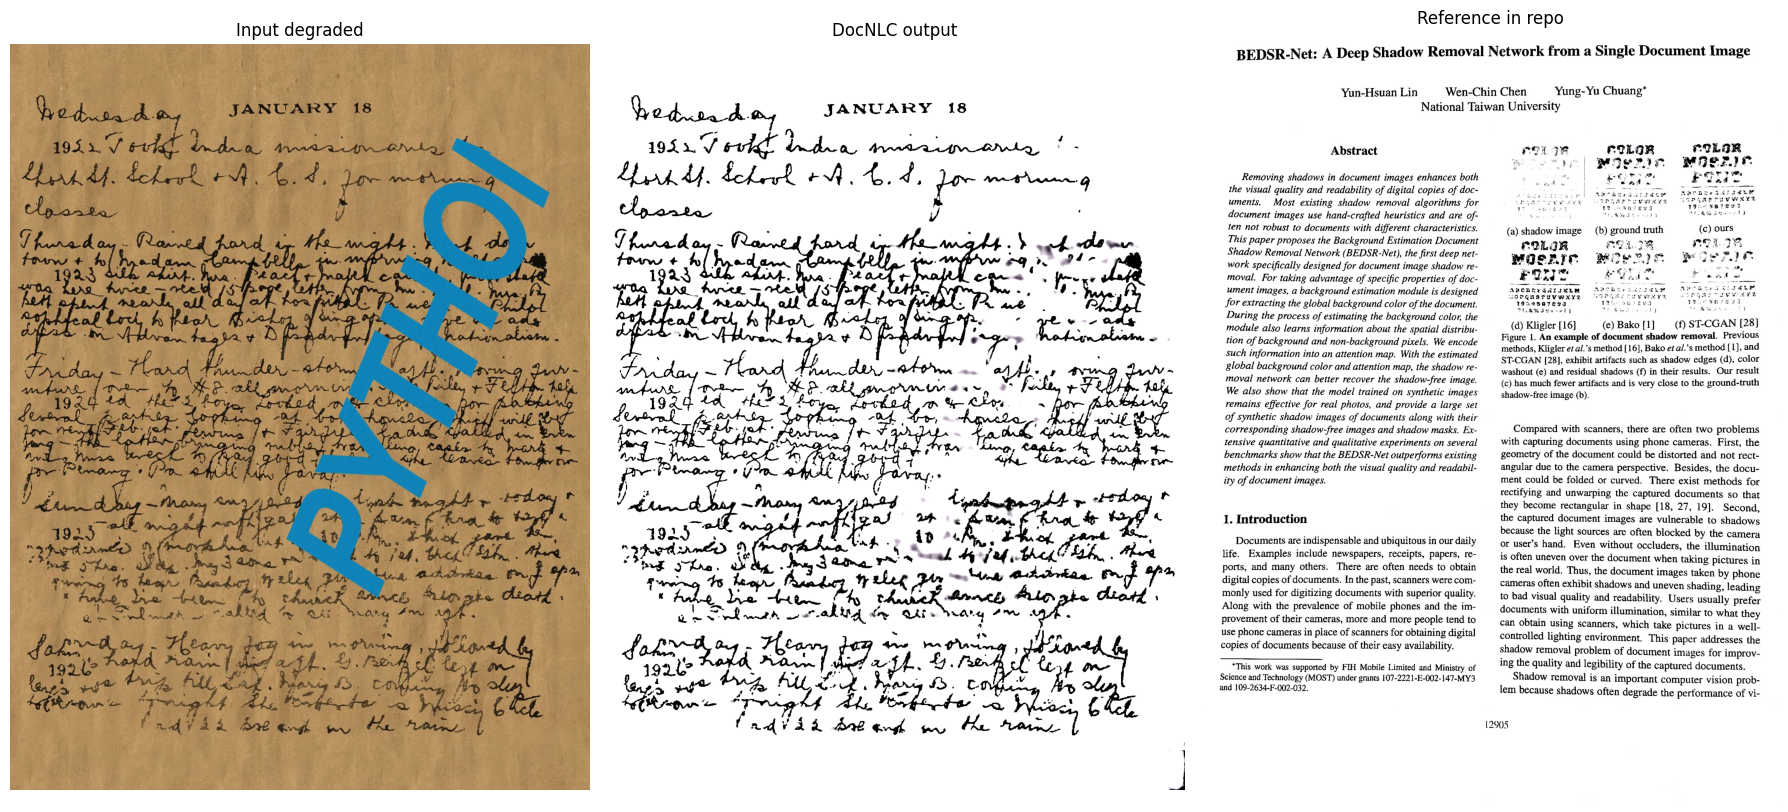

In [10]:
def bgr_to_rgb_uint8(image):
    if image.dtype != np.uint8:
        image = np.clip(image * 255.0, 0, 255).round().astype(np.uint8)
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

images = [("Input degraded", bgr_to_rgb_uint8(original_bgr)), ("DocNLC output", bgr_to_rgb_uint8(result_bgr))]

if REFERENCE_IMAGE.exists():
    ref = cv2.imread(str(REFERENCE_IMAGE), cv2.IMREAD_UNCHANGED)
    if ref is not None:
        if ref.ndim == 2:
            ref = np.repeat(ref[:, :, None], 3, axis=2)
        images.append(("Reference in repo", bgr_to_rgb_uint8(ref)))

plt.figure(figsize=(6 * len(images), 8))
for idx, (title, image) in enumerate(images, 1):
    plt.subplot(1, len(images), idx)
    plt.imshow(image)
    plt.title(title)
    plt.axis("off")
plt.tight_layout()
plt.show()

## 8. Chạy với ảnh khác

Đổi `CUSTOM_IMAGE` sang ảnh tài liệu bạn muốn demo. Kết quả sẽ được lưu trong `demo_outputs_cpu/`.

CPU inference patches (validation-compatible): 100%|██████████| 6/6 [00:01<00:00,  3.59it/s]

Done in 1.68s on cpu.
Saved: /Users/mac/Documents/DATN/source/DocNLC/demo_outputs_cpu/rect_1_docnlc.png


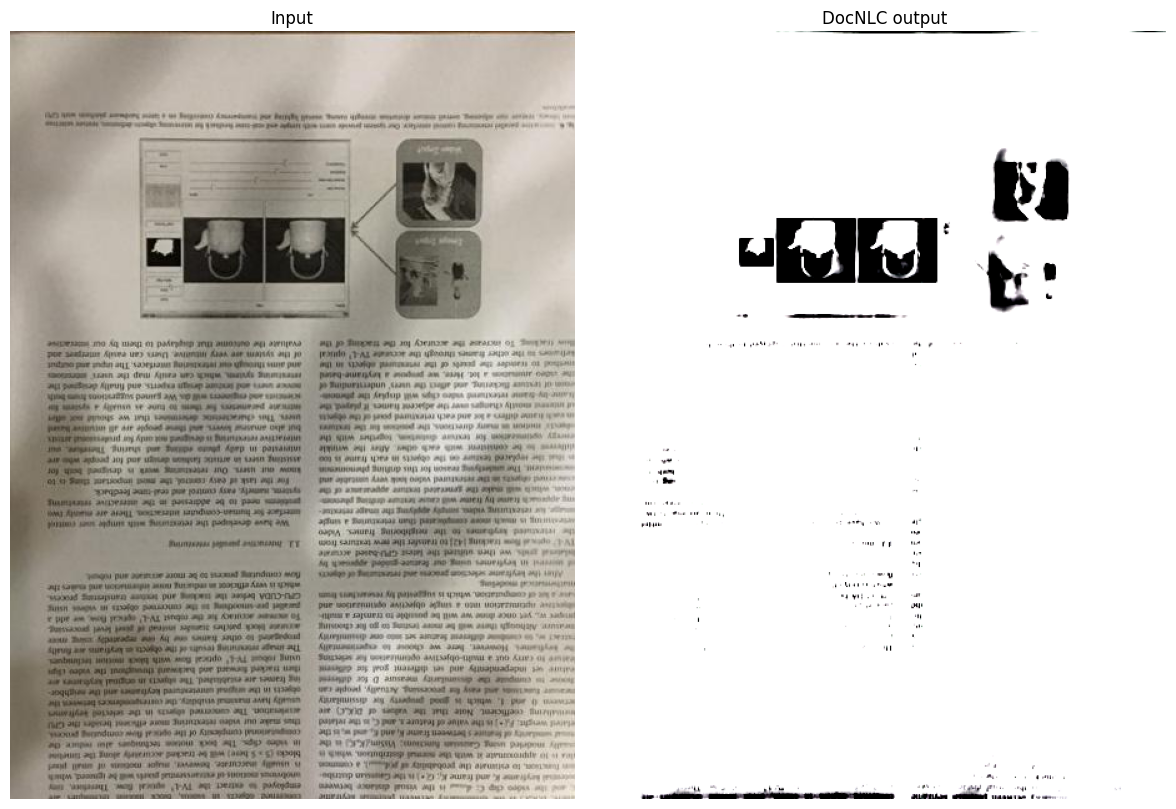

In [22]:
CUSTOM_IMAGE = Path('/Users/mac/Downloads/rect_1.jpg')  # ví dụ: Path('/path/to/document.jpg')

custom_input_bgr, custom_result_bgr, custom_elapsed = run_docnlc_inference(Path(CUSTOM_IMAGE), model, device)
custom_output_path = OUTPUT_DIR / f"{Path(CUSTOM_IMAGE).stem}_docnlc.png"
cv2.imwrite(str(custom_output_path), custom_result_bgr)

print(f"Done in {custom_elapsed:.2f}s on {device}.")
print("Saved:", custom_output_path)

plt.figure(figsize=(12, 8))
plt.subplot(1, 2, 1)
plt.imshow(bgr_to_rgb_uint8(custom_input_bgr))
plt.title("Input")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(bgr_to_rgb_uint8(custom_result_bgr))
plt.title("DocNLC output")
plt.axis("off")
plt.tight_layout()
plt.show()

## 9. Ghi chú demo

- Hãy đặt `CKPT_PATH` thành checkpoint best đã lưu sau fine-tune trước khi đối chiếu ảnh.
- Ảnh mẫu mặc định: `TestImages/yeah.jpg`.
- Toàn bộ model và tensor được đặt trên `torch.device("cpu")`; thời gian chạy sẽ lâu hơn bản GPU.
- Hàm inference cố ý chạy từng patch giống `SIEN_model.val()` và không threshold, vì đây là luồng dùng để tính validation PSNR và lưu `val_images/best`.
- `SIEN_model.test()` hiện threshold output ở `0.95`, nên kết quả của luồng đó sẽ khác ảnh best ngay cả với cùng checkpoint và cùng ảnh input.